# Package Importation 

In [2]:
import pandas as pd 
import numpy as np 
import missingno as msno
# Data Visualisation Packages 
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px


# from fancyimpute import KNN ###Question - whats the difference between fancy inpute KNN and sklearn knn impute??
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder


# Load Data

In [4]:
data = pd.read_csv('melb_data.csv')
df = data.copy(deep=True)

In [5]:
df.shape

(13580, 21)

# Data Overview

In [7]:
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [8]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [9]:
df.describe(include='O')

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,58,33,8
top,Reservoir,36 Aberfeldie St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,473,1163,4695


# Questions 

In [11]:
def missing_value_summary(df):
    Missing_value_col_summary = 
        df.isnull().sum().reset_index().rename(columns={'index': 'column', 0: 'missing_count'})
    Missing_value_col_summary['missing_percent'] = (
        Missing_value_col_summary['missing_count'] / len(df) * 100)

    Missing_value_col_summary = Missing_value_col_summary[
        Missing_value_col_summary["missing_count"] > 0
    ]
    Missing_value_col_summary.sort_values(
        by="missing_percent", ascending=False, inplace=True
    )
    Missing_value_col_summary.reset_index(drop=True, inplace=True)

    return Missing_value_col_summary

,column,missing_count,missing_percent
0,BuildingArea,6450,47.496318
1,YearBuilt,5375,39.580265
2,CouncilArea,1369,10.081001
3,Car,62,0.456554


#### 1.	Using methods for MNAR and MAR identification, find which variables belong to either.

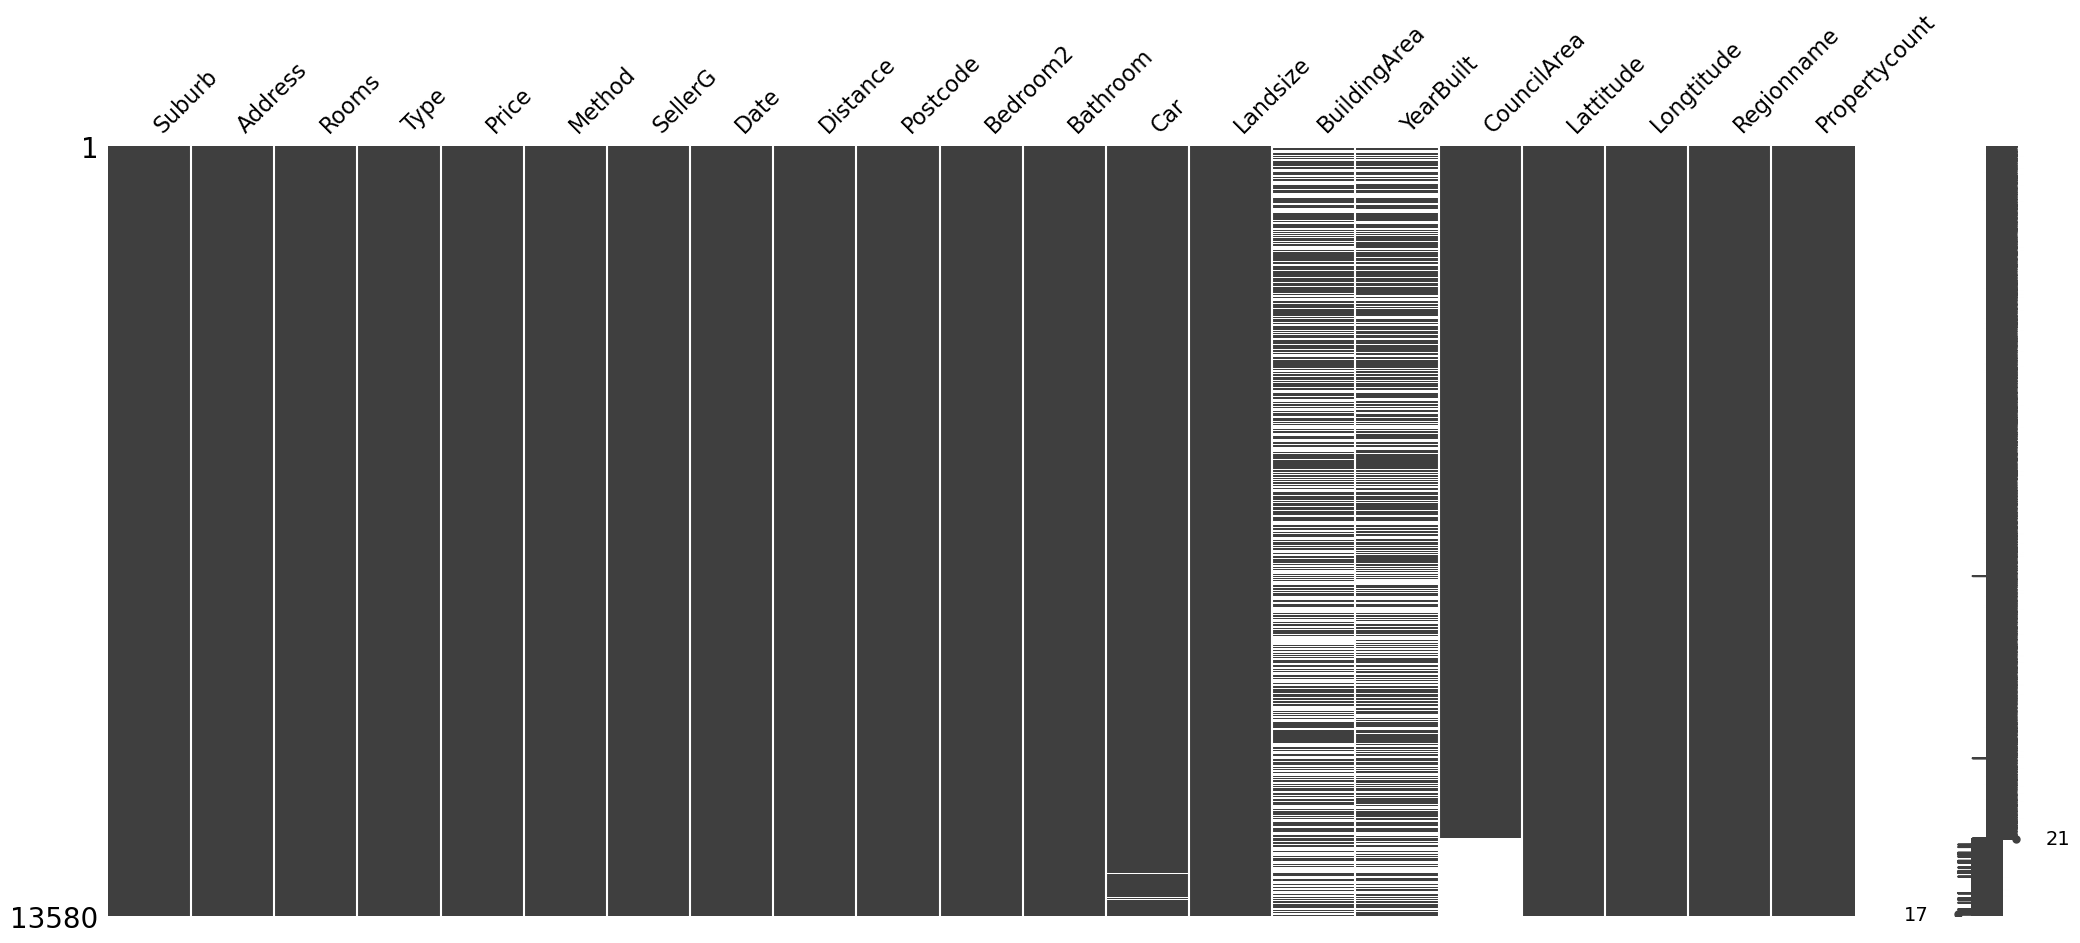

In [13]:
msno.matrix(df)
plt.show()

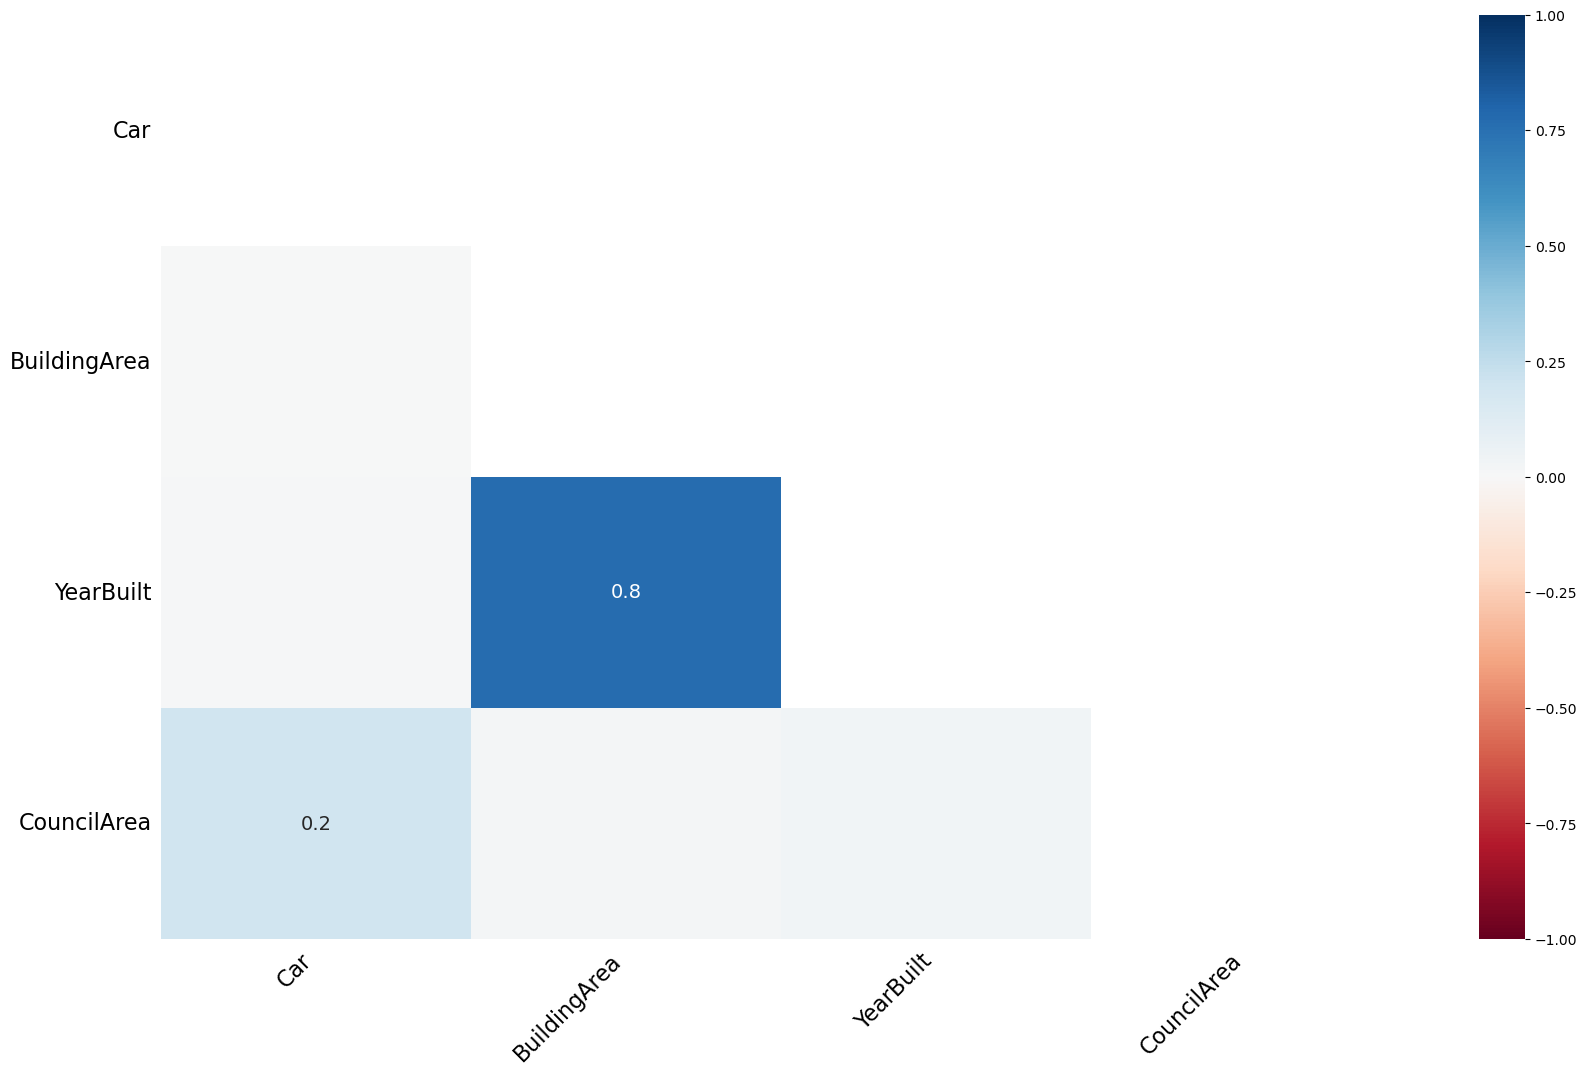

In [14]:
msno.heatmap(df)
plt.show()

##### commentary: 
- YearBuilt and BuildingArea are likely to be MAR due to the high correlation of 0.8 
- CouncilArea and Car have a weak MAR and could potentially be MNAR

#### 2.	Use a host of imputation methods on the data, produce visuals and statistics to assess the performance of the different cleaning techniques

Methodology:

BuildingArea :  Numeric values + strong missingness correlation = KNN and IterativeImputer

YearBuilt : Numeric values + strong missingness correlation = KNN and IterativeImputer

CouncilArea : Categorical values + weak missingness correlation = mode 

Car: Numeric values + weak missingness correlation = median or KNN 

##### Impute car variable

In [19]:
# # Mode imputation
# imp_mode = SimpleImputer(strategy='most_frequent')
# df['CouncilArea_mode'] = imp_mode.fit_transform(df[['CouncilArea']])

# #Constant imputation-"Unknown"
# imp_const = SimpleImputer(strategy='constant', fill_value='Unknown')
# df['CouncilArea_const'] = imp_const.fit_transform(df[['CouncilArea']])


NameError: name 'SimpleImputer' is not defined

##### Impute CouncilArea

In [25]:
df['CouncilArea'] = df['CouncilArea'].fillna(df['CouncilArea'].mode()[0])

##### Impute YearBuilt and BuildingArea

In [23]:
from sklearn.impute import KNNImputer

df['YearBuilt'] = df['YearBuilt'].round().astype('Int64')

def knn_impute(df, n_neighbors=3):
    
    imputer = KNNImputer(n_neighbors=n_neighbors)


    cols = ['YearBuilt', 'BuildingArea']


    df[cols] = imputer.fit_transform(df[cols])

    return df


#### 3.	Assess the distribution of numerical variables, using two visualisation methods.
#### a.	Do any of the variables follow a normal distribution?
#### b.	Assess the level of skew in the variables
#### c.	Identify visually and statistically any anomalies in the data

In [27]:
df.describe().columns.to_list()

['Rooms',
 'Price',
 'Distance',
 'Postcode',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'Lattitude',
 'Longtitude',
 'Propertycount']

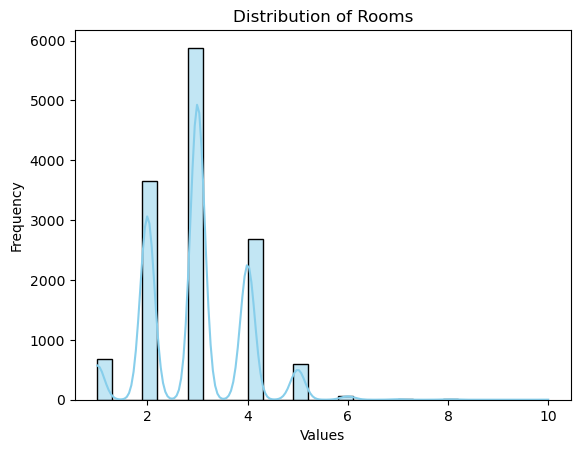

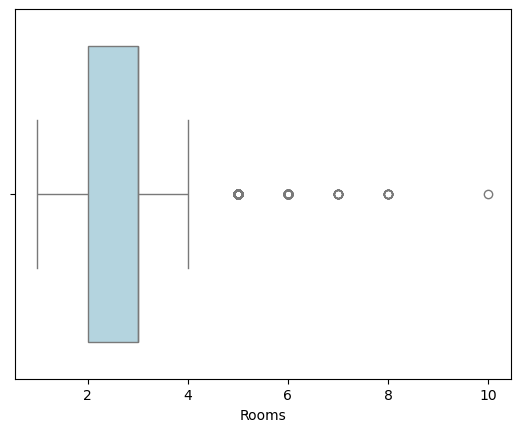

In [29]:
sns.histplot(df['Rooms'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Rooms')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Rooms'], color='lightblue');

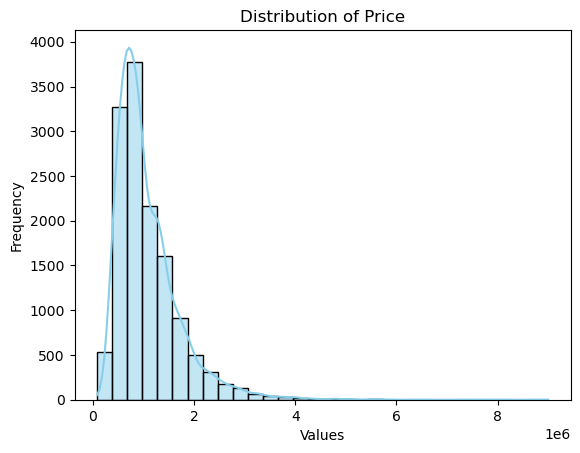

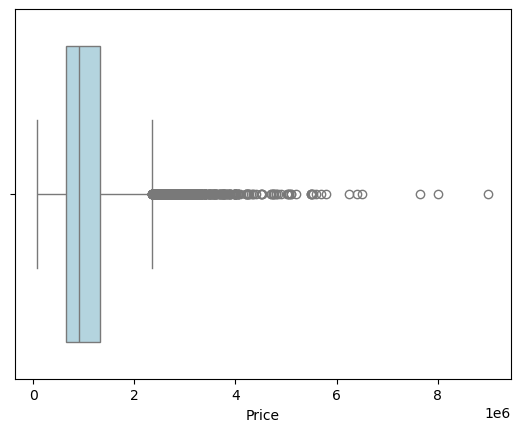

In [30]:
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Price')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Price'], color='lightblue');

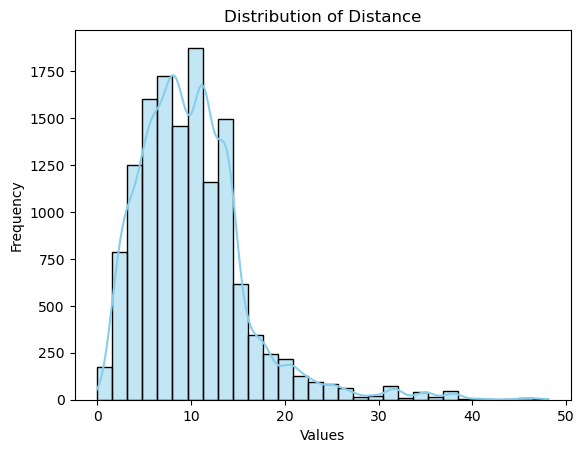

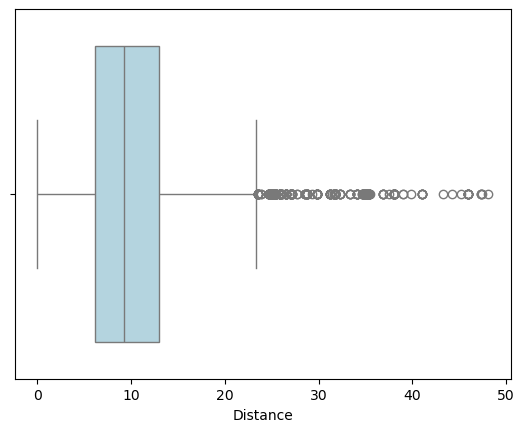

In [31]:
sns.histplot(df['Distance'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Distance')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Distance'], color='lightblue');

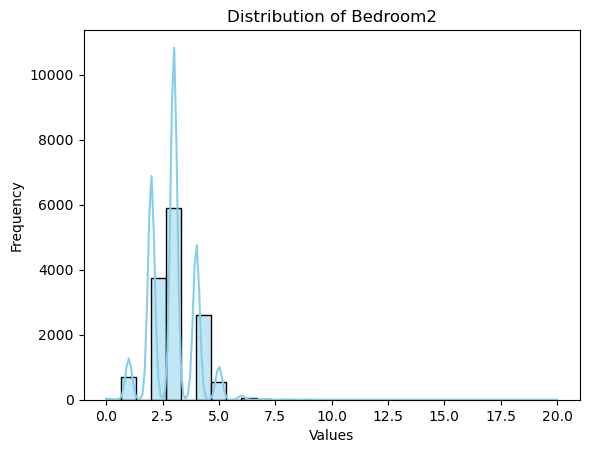

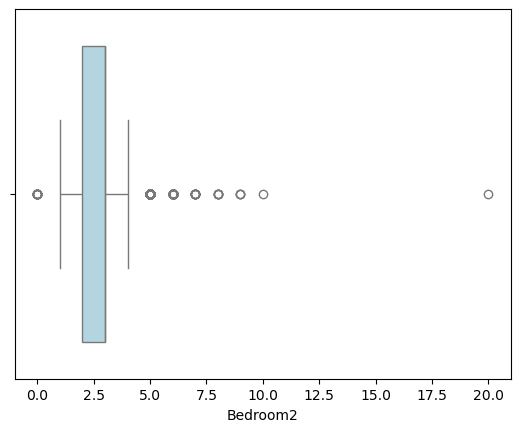

In [33]:
sns.histplot(df['Bedroom2'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Bedroom2')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Bedroom2'], color='lightblue');

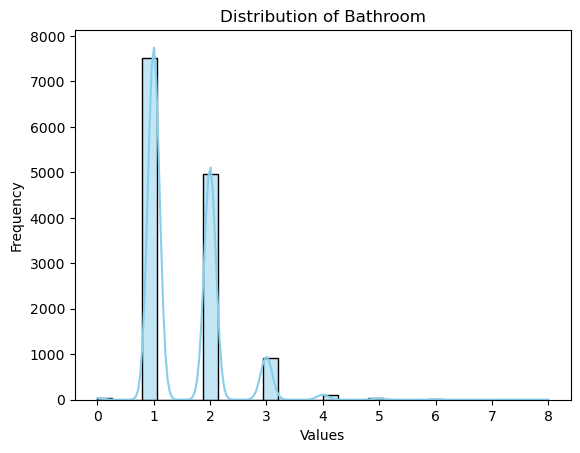

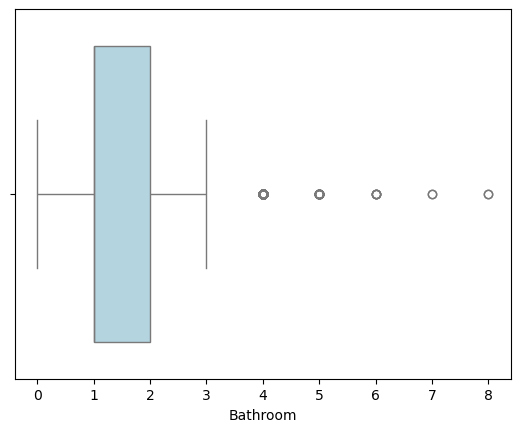

In [34]:
sns.histplot(df['Bathroom'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Bathroom')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Bathroom'], color='lightblue');

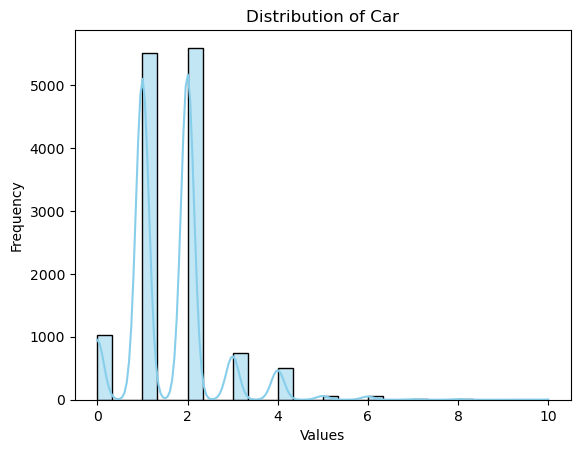

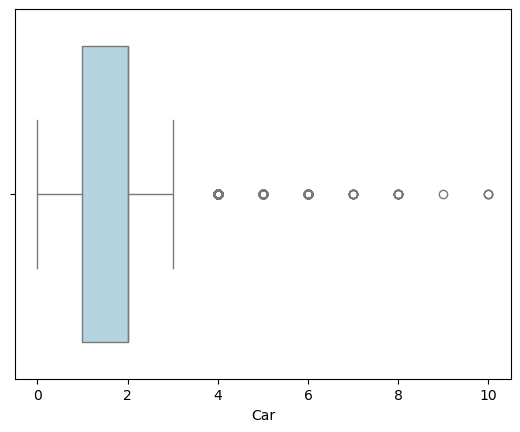

In [36]:
sns.histplot(df['Car'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Car')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Car'], color='lightblue');

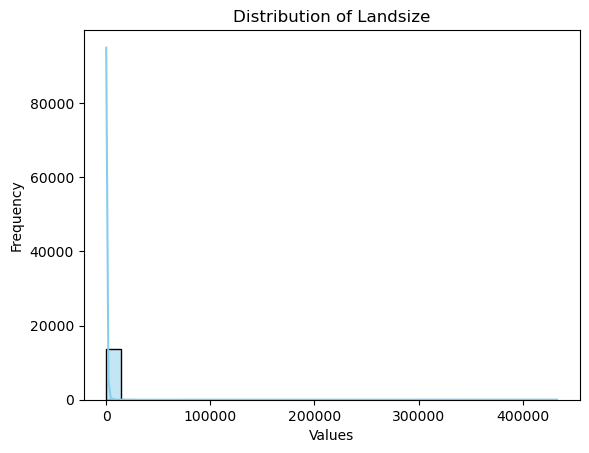

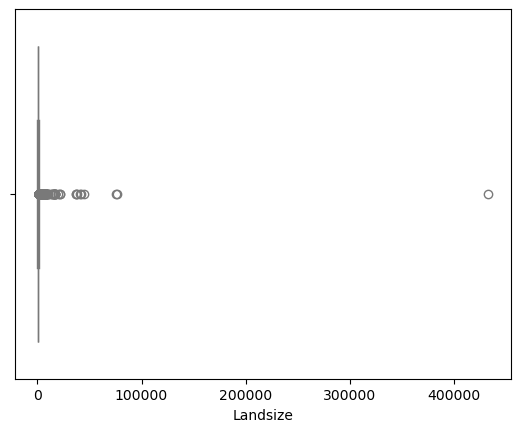

In [37]:
sns.histplot(df['Landsize'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Landsize')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Landsize'], color='lightblue');

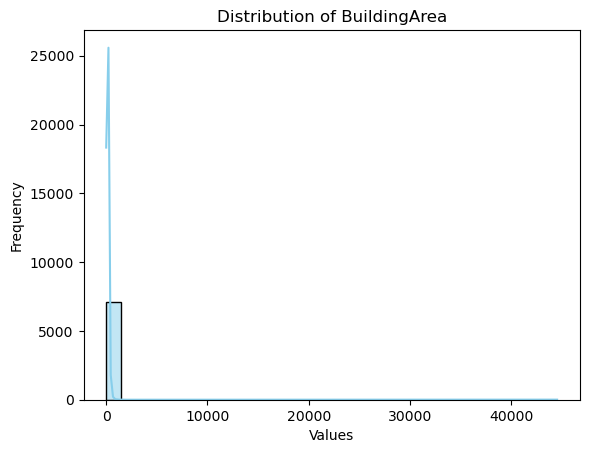

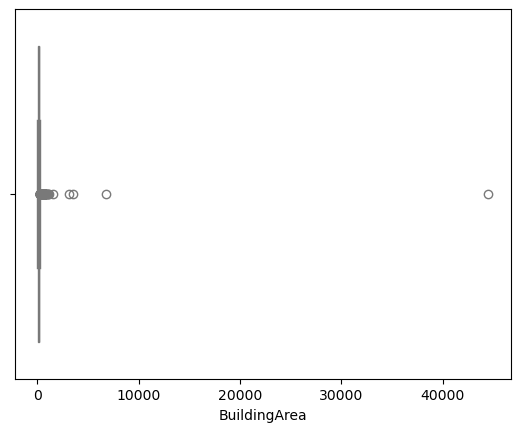

In [39]:
sns.histplot(df['BuildingArea'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of BuildingArea')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['BuildingArea'], color='lightblue');

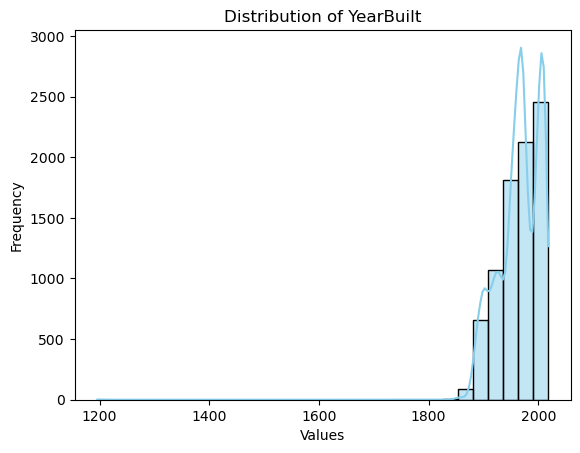

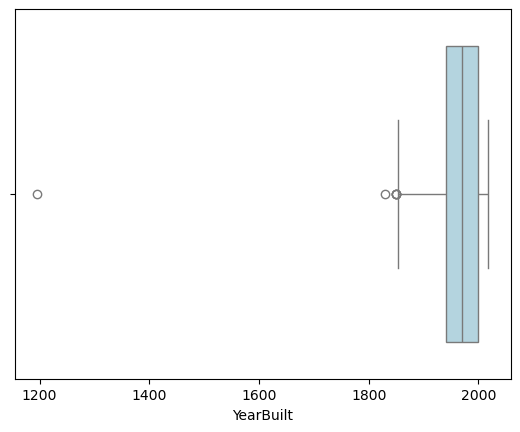

In [40]:
sns.histplot(df['YearBuilt'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of YearBuilt')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['YearBuilt'], color='lightblue');

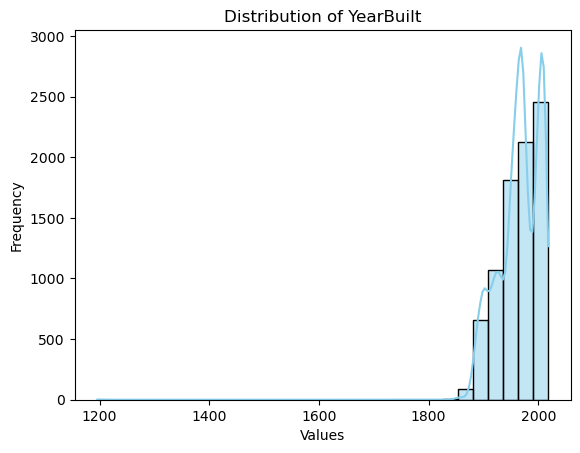

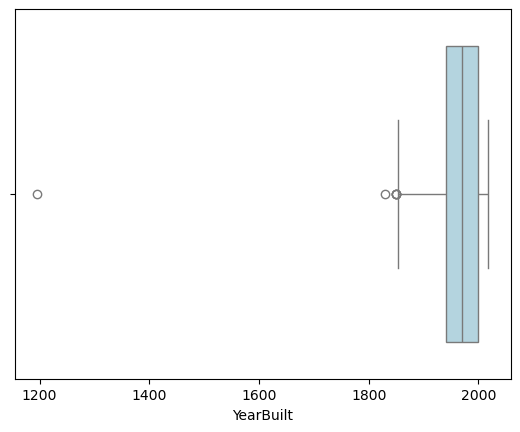

In [41]:
sns.histplot(df['YearBuilt'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of YearBuilt')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['YearBuilt'], color='lightblue');

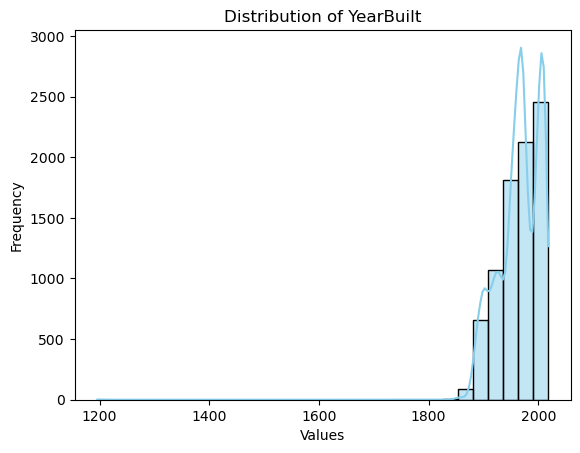

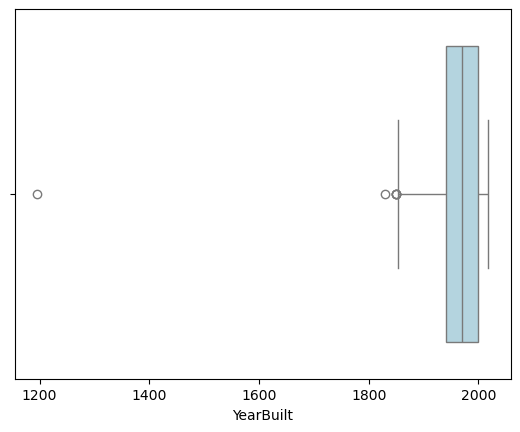

In [43]:
sns.histplot(df['YearBuilt'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of YearBuilt')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['YearBuilt'], color='lightblue');

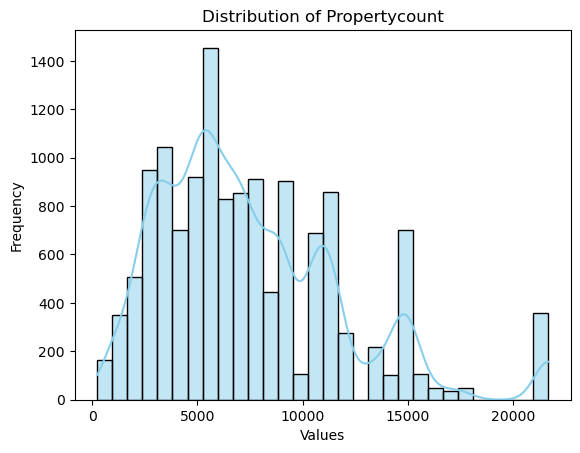

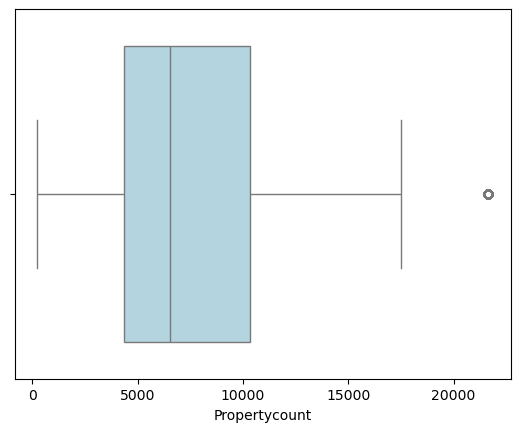

In [44]:
sns.histplot(df['Propertycount'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Propertycount')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=df['Propertycount'], color='lightblue');

#### 4.	Load the data column as a date variable and create three new variables:
#### a.	Month
#### b.	Season
#### c.	Year

In [47]:
df.columns.to_list()

['Suburb',
 'Address',
 'Rooms',
 'Type',
 'Price',
 'Method',
 'SellerG',
 'Date',
 'Distance',
 'Postcode',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'CouncilArea',
 'Lattitude',
 'Longtitude',
 'Regionname',
 'Propertycount']

In [49]:
#year
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['year'] = df['Date'].dt.year

In [50]:
#month
df['month_num'] = df['Date'].dt.month
df['month_name'] = df['Date'].dt.month_name()

In [52]:
#season
def get_season(month):
    if month in [1, 2, 12]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Date'].dt.month.apply(get_season)

#### 5.	Produce a heat map for the numerical data
#### a.	Which variables show interesting relationships
#### b.	Is there any suggestion of multicollinearity in the dataset

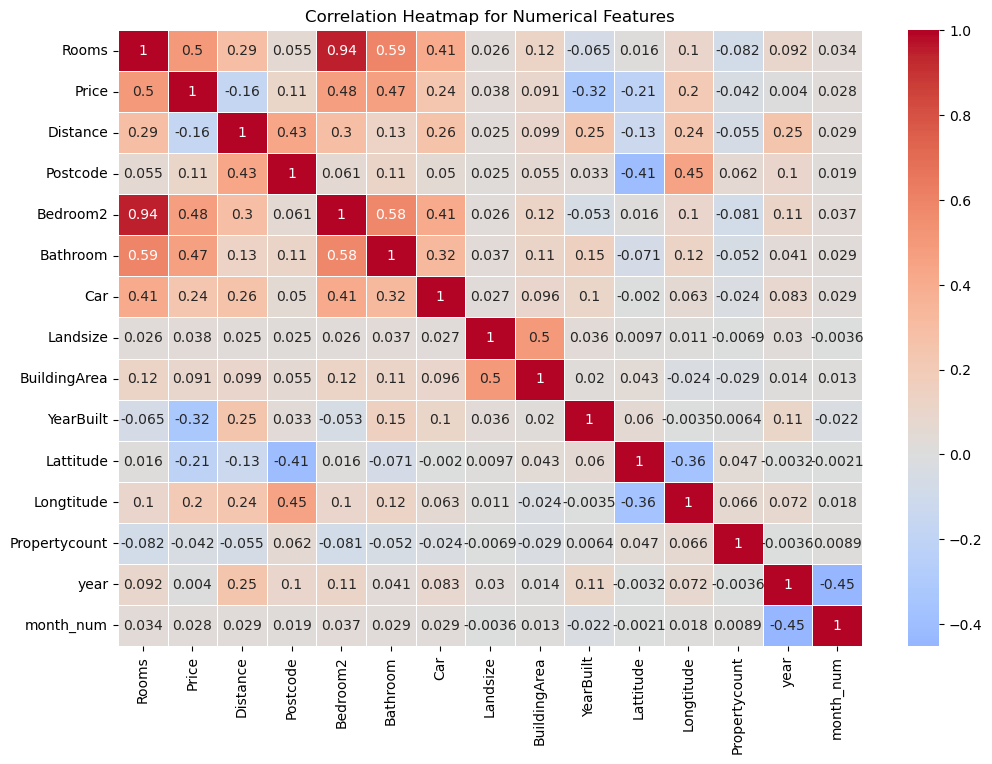

In [54]:
num_df = df.select_dtypes(include=['number'])
corr = num_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

#### 6.	Turn the price variable into a cut and produce a countplot and crosstable with other grouping varibles: Council Area, Region Name, Method,type, Car (you may wish to covert it into a string)
#### a.	Assess key trends. Does there seem to profiles within the data?

In [57]:
# Convert Car to string
if 'Car' in df.columns:
    df['Car'] = df['Car'].astype(str)

In [92]:
df["z"] = (df["Price"] - df["Price"].mean()) / df["Price"].std()

df["PriceCategory"] = pd.cut(
    df["z"],
    bins=[-999, -0.5, 0.5, 999],
    labels=["LowPrice", "AveragePrice", "HighPrice"])

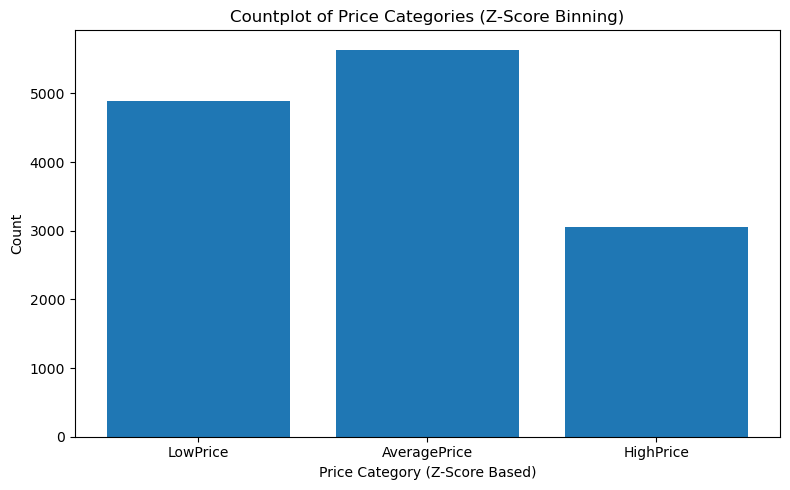

In [94]:

counts = df["PriceCategory"].value_counts().reindex(["LowPrice", "AveragePrice", "HighPrice"])

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Price Category (Z-Score Based)")
plt.ylabel("Count")
plt.title("Countplot of Price Categories (Z-Score Binning)")
plt.tight_layout()
plt.show()

In [98]:
# Crosstabs
ct_council = pd.crosstab(df["PriceCategory"], df["CouncilArea"])
ct_region = pd.crosstab(df["PriceCategory"], df["Regionname"] )
ct_method = pd.crosstab(df["PriceCategory"], df["Method"])
ct_type = pd.crosstab(df["PriceCategory"], df["Type"])
ct_car = pd.crosstab(df["PriceCategory"], df["Car"])

ct_council.head(), ct_region.head(), ct_method.head(), ct_type.head(), ct_car.head()

(CouncilArea    Banyule  Bayside  Boroondara  Brimbank  Cardinia  Casey  \
 PriceCategory                                                            
 LowPrice           256       49         245       342         8     33   
 AveragePrice       257      141         208        82         0      5   
 HighPrice           81      299         707         0         0      0   
 
 CouncilArea    Darebin  Frankston  Glen Eira  Greater Dandenong  ...  \
 PriceCategory                                                    ...   
 LowPrice           364         39        240                 38  ...   
 AveragePrice       459         13        408                 14  ...   
 HighPrice          111          1        200                  0  ...   
 
 CouncilArea    Moreland  Nillumbik  Port Phillip  Stonnington  Unavailable  \
 PriceCategory                                                                
 LowPrice            905          8           277          271            0   
 AveragePrice      

#### 7.	Use methods for calculating effect size for numerical variables and assess the association effect on each pair (also include level of significance)

#### 8.	Use methods for calculating effect size for Categorical variables and assess the association effect on each pair (also include level of significance)

#### 9.	Use methods for calculating effect size for Categorical variables and assess the association effect on each pair (also include level of significance)

#### 10.	Produce your final analysis on the data considering all points made earlier.

In [ ]:
### VIF 
## 